# Variant functional consequences

This notebook provides a summary of the functional consequences of lead variants


## Data Loading

The data required for the analysis is loaded from the `computed maf` dataset.


In [41]:
from __future__ import annotations

import patchworklib as pw
import plotnine as pn
from gentropy.common.session import Session
from pyspark.sql import Window
from pyspark.sql import functions as f

from manuscript_methods import OpenTargetsTheme, calculate_protein_altering_proportion, group_statistics
from manuscript_methods.datasets import LeadVariantEffect

In [42]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})
lead_maf_dataset_path = "../../data/qualified_lead_variant_effect"

In [43]:
session.spark

In [44]:
# Limit to only cis-pQTL, GWAS and eQTL studies
dataset = LeadVariantEffect.from_parquet(session, lead_maf_dataset_path)

In [45]:
dataset.df.show(1)

+---------------+--------------------+--------------------+------------+------+--------------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+------------------------+
|      variantId|             variant|        studyLocusId|     studyId|geneId|        originalBeta|originalStandardError|     locusStatistics|finemappingMethod|isTransQtl|       variantEffect|majorLdPopulation|majorLdPopulationMaf| majorLdPopulationAf|   variantStatistics|     studyStatistics|  rescaledStatistics|leadVariantConsequence|traitFromSourceMappedIds|
+---------------+--------------------+--------------------+------------+------+--------------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+-----------------

In [46]:
si = session.spark.read.parquet("../../data/study")
si.count()

1966178

In [47]:
df = dataset.df.drop("geneId").join(
    si.select("studyId", "diseaseIds", "geneId", "biosampleId"), on="studyId", how="inner"
)
df.count()

459516

In [48]:
maf_vep_dataset = df.select(
    "variantId",
    "leadVariantConsequence.*",
    "studyStatistics.studyType",
    "majorLdPopulationMaf.value",
    "rescaledStatistics.*",
    "geneId",
    "diseaseIds",
).select(
    "variantId",
    "mostSevereConsequence.type",
    "mostSevereConsequence.transcriptConsequence.consequenceScore",
    "studyType",
    "value",
    "estimatedBeta",
    "geneId",
    "diseaseIds",
)

In [49]:
maf_vep_dataset.show(1)

+---------------+--------------+----------------+------------+-------------------+-------------------+------+-------------+
|      variantId|          type|consequenceScore|   studyType|              value|      estimatedBeta|geneId|   diseaseIds|
+---------------+--------------+----------------+------------+-------------------+-------------------+------+-------------+
|10_11676714_A_G|in-gene-effect|             0.1|gwas-disease|0.48184912081678954|0.09068525958503834|  NULL|[EFO_1001870]|
+---------------+--------------+----------------+------------+-------------------+-------------------+------+-------------+
only showing top 1 row



In [50]:
gwas_data = maf_vep_dataset.filter(f.col("studyType").startswith("gwas")).dropDuplicates(["variantId", "diseaseIds"])


qtl_data = maf_vep_dataset.filter(f.col("studyType").isin(["eqtl", "cis-pqtl"])).dropDuplicates(["variantId", "geneId"])

maf_vep_dataset = gwas_data.union(qtl_data)
maf_vep_dataset.count()

120809

In [51]:
maf_vep_dataset_all = maf_vep_dataset.toPandas()
maf_vep_dataset_all["PAV"] = maf_vep_dataset_all["consequenceScore"] >= 0.66
maf_vep_dataset_all

,variantId,type,consequenceScore,studyType,value,estimatedBeta,geneId,diseaseIds,PAV
0,10_100315722_G_A,in-gene-effect,0.1,gwas-measurement,0.186085,0.018535,None,[EFO_0004309],False
1,10_100315722_G_A,in-gene-effect,0.1,gwas-measurement,0.186085,-0.223732,None,[EFO_0005059],False
2,10_100315722_G_A,in-gene-effect,0.1,gwas-measurement,0.326382,0.012532,None,[EFO_0005091],False
3,10_100315722_G_A,in-gene-effect,0.1,gwas-measurement,0.186085,0.081737,None,[EFO_0005110],False
4,10_100315722_G_A,in-gene-effect,0.1,gwas-measurement,0.186085,-0.186961,None,[EFO_0010406],False
...,...,...,...,...,...,...,...,...,...
120804,X_8471341_T_C,in-gene-effect,0.0,eqtl,0.366575,-0.833097,ENSG00000205642,[],False
120805,X_84940129_T_C,in-gene-effect,0.0,eqtl,0.319475,-0.680359,ENSG00000155008,[],False
120806,X_9712962_TC_T,in-gene-effect,0.1,eqtl,0.498361,-0.460493,ENSG00000101849,[],False
120807,X_9715526_C_T,in-gene-effect,0.1,eqtl,0.205449,-0.281452,ENSG00000101849,[],False


In [ ]:
maf_vep_dataset_all.to_csv("../../data/for_figure_2_part_1.csv", index=False)

## Plots v1


In [ ]:
maf_vep_dataset_all = pd.read_csv("../../data/for_figure_2_part_1.csv")

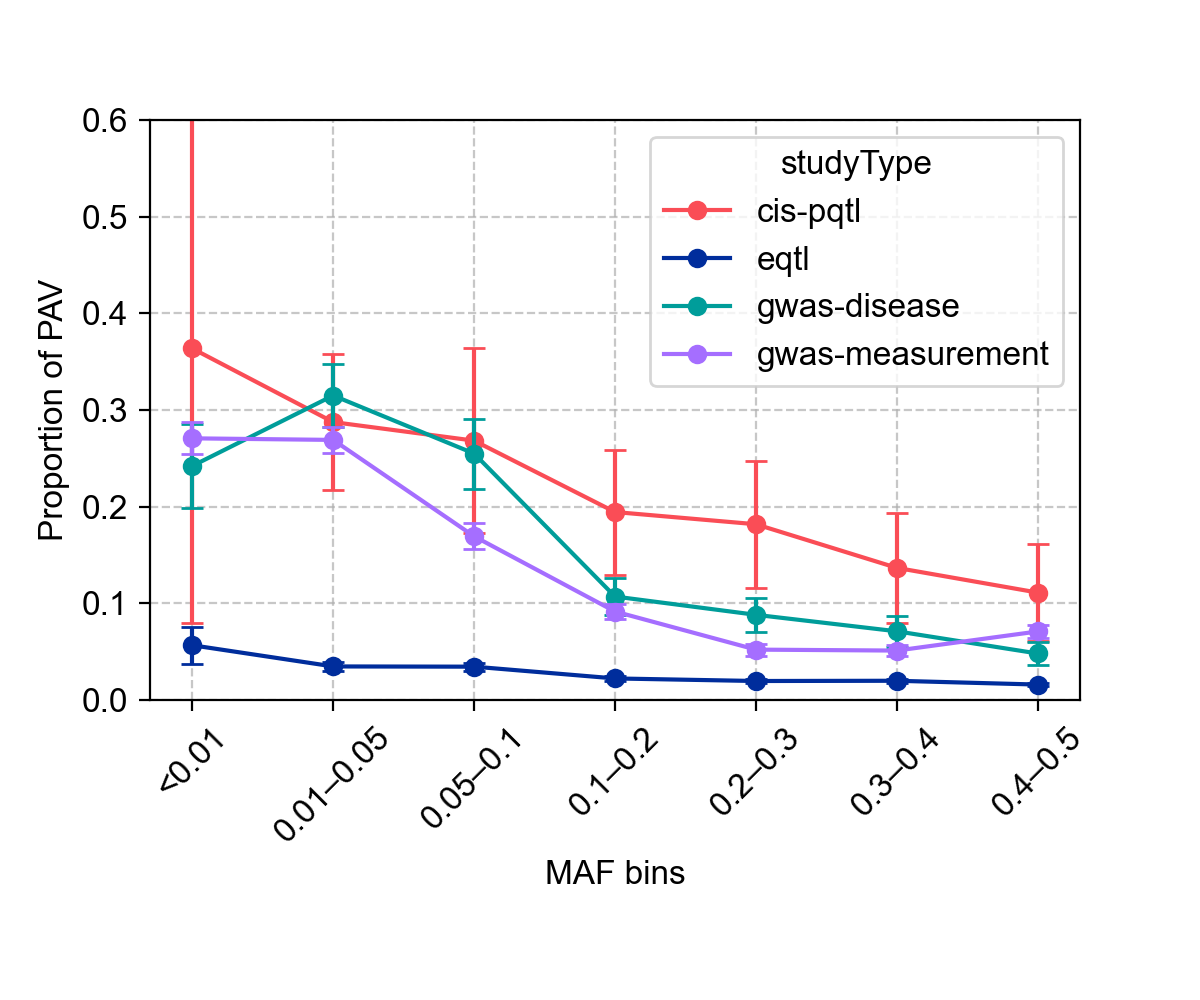

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df = maf_vep_dataset_all
df = maf_vep_dataset_all.copy()
df["PAV_int"] = df["PAV"].astype(int)

# Определяем интервалы
bins = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
labels = ["<0.01", "0.01–0.05", "0.05–0.1", "0.1–0.2", "0.2–0.3", "0.3–0.4", "0.4–0.5"]

df["maf_bin"] = pd.cut(df["value"], bins=bins, labels=labels, include_lowest=True)

# Группируем по studyType + maf_bin
bin_stats = df.groupby(["studyType", "maf_bin"])["PAV_int"].agg(["mean", "count", "sum"]).reset_index()
bin_stats.rename(columns={"mean": "p", "count": "n", "sum": "n_pav"}, inplace=True)

# SE и доверительные интервалы
bin_stats["SE"] = np.sqrt(bin_stats["p"] * (1 - bin_stats["p"]) / bin_stats["n"])
bin_stats["CI_lower"] = (bin_stats["p"] - 1.96 * bin_stats["SE"]).clip(0, 1)
bin_stats["CI_upper"] = (bin_stats["p"] + 1.96 * bin_stats["SE"]).clip(0, 1)

colors = {"cis-pqtl": "#fa4d56", "eqtl": "#002d9c", "gwas-disease": "#009d9a", "gwas-measurement": "#a56eff"}

plt.figure(figsize=(6, 5))
plt.subplots_adjust(bottom=0.3)
for study, sub in bin_stats.groupby("studyType"):
    color = colors.get(study, "black")  # fallback to black if studyType not in dict
    # Line + markers
    plt.plot(sub["maf_bin"], sub["p"], marker="o", linestyle="-", label=study, color=color)
    # CI as error bars
    plt.errorbar(sub["maf_bin"], sub["p"], yerr=1.96 * sub["SE"], fmt="none", capsize=4, color=color)


plt.xlabel("MAF bins")
plt.ylabel("Proportion of PAV")
# plt.title("PAV proportion by MAF bins (with 95% CI) per studyType")
plt.xticks(rotation=45)
plt.ylim(0, 0.6)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="studyType")
plt.show()

## Proportion of altering / total vs maf bins


In [55]:
PRECISION = 20  # Needs to be the power of 10
PRECISION_FACTOR = len(str(PRECISION))  # Number of digits in the precision factor
upper_limit = f.ceil(f.col("value") * PRECISION) / PRECISION
lower_limit = f.floor(f.col("value") * PRECISION) / PRECISION
bucket_dataset = (
    maf_vep_dataset.withColumns(
        {
            "minRange": f.round(
                f.when(upper_limit == lower_limit, lower_limit - 1 / PRECISION).otherwise(lower_limit), PRECISION_FACTOR
            ),
            "maxRange": upper_limit,
        }
    )
    .withColumn("midPoint", f.round((f.col("minRange") + f.col("maxRange")) / 2, PRECISION_FACTOR + 1))
    .withColumn("bucket", f.concat(f.col("minRange"), f.lit("-"), f.col("maxRange")))
    .withColumn("vepProportion", calculate_protein_altering_proportion(f.col("consequenceScore")))
    .withColumn(
        "meanAbsEstimatedBeta", f.mean(f.abs(f.col("estimatedBeta"))).over(Window.partitionBy("bucket", "studyType"))
    )
    .withColumn(
        "stderrAbsEstimatedBeta",
        f.stddev(f.abs(f.col("estimatedBeta"))).over(Window.partitionBy("bucket", "studyType"))
        / f.sqrt(f.count(f.col("estimatedBeta")).over(Window.partitionBy("bucket", "studyType"))),
    )
    .withColumn("intervalAbsEstimatedBeta", f.lit(1.96) * f.col("stderrAbsEstimatedBeta"))
    .orderBy("bucket")
    .select(
        "variantId",
        "type",
        "vepProportion.*",
        "consequenceScore",
        "studyType",
        "bucket",
        f.col("value").alias("MAF"),
        "minRange",
        "maxRange",
        "midPoint",
        "stderrAbsEstimatedBeta",
        "meanAbsEstimatedBeta",
        "intervalAbsEstimatedBeta",
    )
)

In [56]:
data = bucket_dataset.drop_duplicates(["bucket", "studyType"]).toPandas()

In [57]:
data.columns

Index(['variantId', 'type', 'nAlteringInBucket', 'nNonAlteringInBucket',
       'alteringProportionInBucket', 'stderr', 'totalInBucket',
       'confidenceInterval', 'consequenceScore', 'studyType', 'bucket', 'MAF',
       'minRange', 'maxRange', 'midPoint', 'stderrAbsEstimatedBeta',
       'meanAbsEstimatedBeta', 'intervalAbsEstimatedBeta'],
      dtype='object')

In [58]:
data

,variantId,type,nAlteringInBucket,nNonAlteringInBucket,alteringProportionInBucket,stderr,totalInBucket,confidenceInterval,consequenceScore,studyType,bucket,MAF,minRange,maxRange,midPoint,stderrAbsEstimatedBeta,meanAbsEstimatedBeta,intervalAbsEstimatedBeta
0,11_4388369_G_A,in-gene-effect,47,109,0.301282,0.036735,156,0.072000,0.33,cis-pqtl,0.0-0.05,0.013822,0.00,0.05,0.025,0.030138,0.721801,0.059071
1,10_100199013_C_T,in-gene-effect,273,7162,0.036718,0.002181,7435,0.004275,0.10,eqtl,0.0-0.05,0.046285,0.00,0.05,0.025,0.006443,1.604491,0.012629
2,10_101281281_C_T,in-gene-effect,342,794,0.301056,0.013610,1136,0.026675,0.10,gwas-disease,0.0-0.05,0.008452,0.00,0.05,0.025,0.012076,0.452043,0.023669
3,10_100564926_G_A,in-gene-effect,1894,5044,0.272989,0.005348,6938,0.010483,0.00,gwas-measurement,0.0-0.05,0.018468,0.00,0.05,0.025,0.003256,0.197645,0.006381
4,10_45620100_A_G,in-gene-effect,22,64,0.255814,0.047049,86,0.092217,0.10,cis-pqtl,0.05-0.1,0.068965,0.05,0.10,0.075,0.030362,0.442312,0.059509
5,10_100196385_GT_G,in-gene-effect,261,7305,0.034496,0.002098,7566,0.004112,0.10,eqtl,0.05-0.1,0.054295,0.05,0.10,0.075,0.004756,1.116353,0.009323
6,10_103069712_C_T,in-gene-effect,140,436,0.243056,0.017872,576,0.035029,0.10,gwas-disease,0.05-0.1,0.069192,0.05,0.10,0.075,0.009418,0.202895,0.018460
7,10_100687890_C_A,in-gene-effect,513,2611,0.164213,0.006628,3124,0.012991,0.00,gwas-measurement,0.05-0.1,0.095901,0.05,0.10,0.075,0.002294,0.081229,0.004497
8,14_23563818_G_A,in-gene-effect,22,61,0.265060,0.048446,83,0.094954,0.66,cis-pqtl,0.1-0.15,0.144497,0.10,0.15,0.125,0.026000,0.401336,0.050959
9,10_100329679_G_A,in-gene-effect,209,7710,0.026392,0.001801,7919,0.003531,0.10,eqtl,0.1-0.15,0.131120,0.10,0.15,0.125,0.004073,0.957193,0.007982


## Mean absolute estimated effect size vs MAF bins


In [ ]:
data.to_csv("../../data/for_figure_2_part_2.csv", index=False)

In [ ]:
data = pd.read_csv("../../data/for_figure_2_part_2.csv")

[0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425, 0.475]


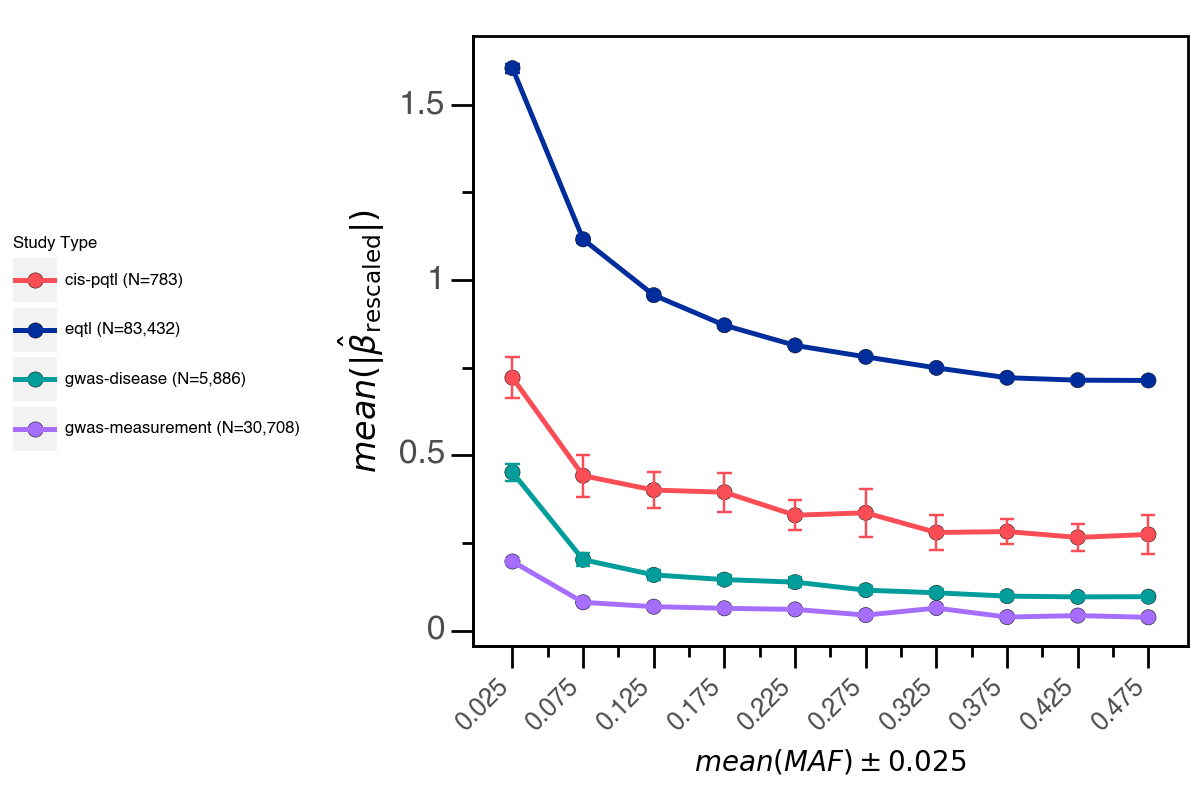

<Figure Size: (600 x 400)>

In [62]:
study_type_totals = data.groupby("studyType")["totalInBucket"].sum()
totals_map = {cat: f"{cat} (N={study_type_totals[cat]:,})" for cat in study_type_totals.index}
data["totals"] = data["studyType"].map(totals_map)
labels = data.drop_duplicates(subset=["studyType", "totals"])
REM = 10
breaks = [x for x in data["midPoint"].unique()]
print(breaks)
plot2 = (
    pn.ggplot(
        data,
        pn.aes(x="midPoint", y="meanAbsEstimatedBeta", fill="studyType"),
    )
    # + pn.geom_col(position="dodge")
    + pn.geom_point(pn.aes(fill="studyType"), stroke=0.1, size=3)
    + pn.geom_errorbar(
        pn.aes(
            ymin="meanAbsEstimatedBeta - intervalAbsEstimatedBeta",
            ymax="meanAbsEstimatedBeta + intervalAbsEstimatedBeta",
            x="midPoint",
            color="studyType",
        ),
        width=0.01,
        # position=pn.position_dodge(width=0.9),
    )
    + pn.labs(
        # title="Proportion of lead variant effects in replicated credible sets",
        x=r"$mean(MAF)\pm{0.025}$",
        y=r"$mean(|\hat{\beta}_{\mathrm{rescaled}}|)$",
    )
    + OpenTargetsTheme.categorical_theme(REM=6)
    + pn.theme(axis_title_x=pn.element_text(size=10))
    # Remove the legend
    # + pn.facet_wrap(nrow=3, facets="studyType", scales="free_y")
    + pn.geom_line(
        pn.aes(x="midPoint", y="meanAbsEstimatedBeta", group="studyType", color="studyType"),
        size=1,
    )
    + pn.scale_fill_manual(
        values=OpenTargetsTheme.categorical_dark_colors,
        name="Study Type",
        labels=totals_map,
    )
    + pn.scale_color_manual(
        values=OpenTargetsTheme.categorical_dark_colors,
        name="Study Type",
        labels=totals_map,
    )
    + pn.scale_x_continuous(
        breaks=[x for x in data["midPoint"].unique()],
        labels=[x for x in data["midPoint"].unique()],
    )
    # + pn.theme(legend_position=(0.70, 0.82))
    + pn.theme(legend_position="left", figure_size=(6, 4))
)
plot2

## Proportion of altering / non altering vs abs(estimatedBeta) bins


In [63]:
PRECISION = 2  # Needs to be the power of 10
PRECISION_FACTOR = len(str(PRECISION)) - 1  # Number of digits in the precision factor
upper_limit = f.ceil(f.col("absEstimatedBeta") * PRECISION) / PRECISION
lower_limit = f.floor(f.col("absEstimatedBeta") * PRECISION) / PRECISION

bucket_dataset = (
    maf_vep_dataset.withColumn("absEstimatedBeta", f.abs("estimatedBeta"))
    .withColumns(
        {
            "minRange": f.when(upper_limit == lower_limit, lower_limit - 1 / PRECISION).otherwise(lower_limit),
            "maxRange": upper_limit,
        }
    )
    .withColumn("midPoint", f.round((f.col("minRange") + f.col("maxRange")) / 2, PRECISION_FACTOR + 2))
    .withColumn("bucket", f.concat(f.col("minRange"), f.lit("-"), f.col("maxRange")))
    .withColumn("vepProportion", calculate_protein_altering_proportion(f.col("consequenceScore")))
    .orderBy("bucket")
    .select(
        "variantId",
        "type",
        "vepProportion.*",
        "consequenceScore",
        "studyType",
        "bucket",
        "absEstimatedBeta",
        "minRange",
        "maxRange",
        "midPoint",
    )
)

In [64]:
data = bucket_dataset.drop_duplicates(["bucket", "studyType"]).toPandas()

## Legend for plots


In [ ]:
labels

['cis-pqtl (N=783)',
 'eqtl (N=83,432)',
 'gwas-disease (N=5,886)',
 'gwas-measurement (N=30,708)']

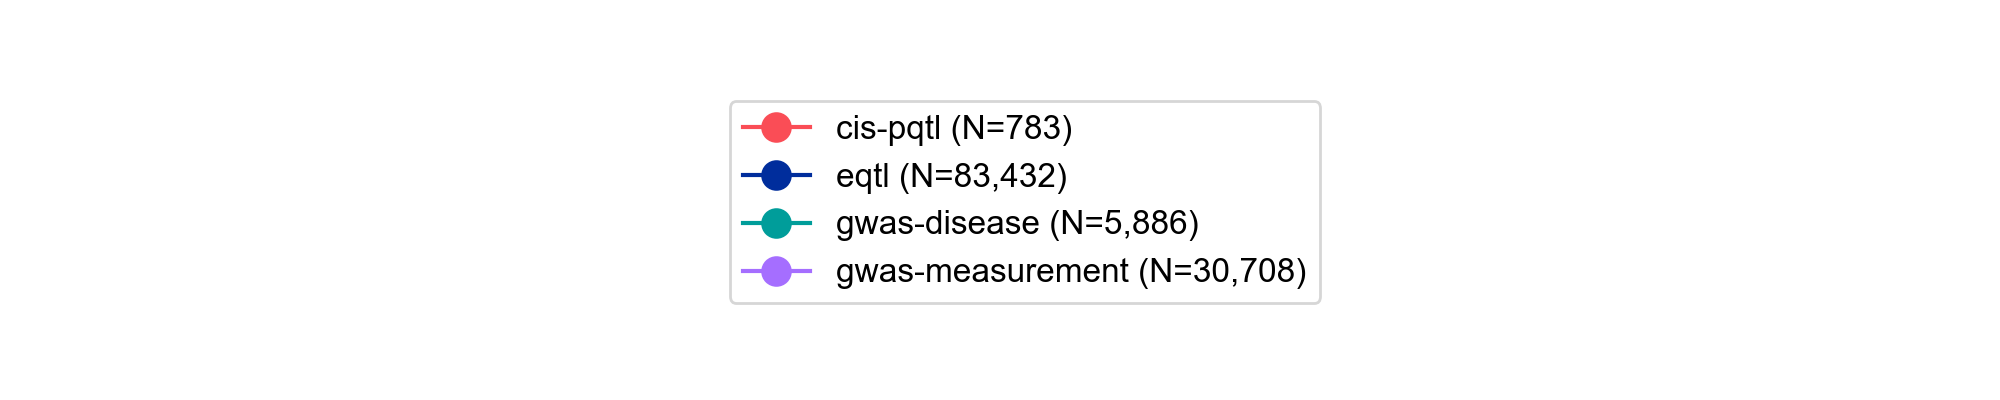

In [69]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(10, 2))
ax = fig.add_subplot(111)

# Create dummy handles (like plot markers or lines) and labels
names = ["cis-pqtl", "eqtl", "gwas-disease", "gwas-measurement"]
colors = OpenTargetsTheme.categorical_dark_colors[: len(names)]
handles = [
    Line2D(
        [0], [0], marker="o", color=color, linestyle="-", label=totals_map[name], markerfacecolor=color, markersize=10
    )
    for name, color in zip(names, colors)
]

labels = [h.get_label() for h in handles]

ax.axis("off")  # Hide the axis

# Add the legend to the axis
legend = ax.legend(handles=handles, labels=labels, loc="center", frameon=True)
fig.show()

## Altering vs non-altering variant counts - IGNORE


In [ ]:
gs = group_statistics(
    maf_vep_dataset.withColumn(
        "variantType", f.when(f.col("consequenceScore") >= 0.66, "altering").otherwise("non-altering")
    ),
    [f.col("variantType"), f.col("studyType")],
)
gs.show()
group_data = gs.toPandas()
group_data["label_above"] = group_data.apply(lambda x: "" if x["percentage"] < 70 else f"{x['%']}%", axis=1)
group_data["label_below"] = group_data.apply(lambda x: "" if x["percentage"] >= 70 else f"{x['%']}%", axis=1)
group_data

+------------+----------------+-----+-----+-------------------+
| variantType|       studyType|count|    %|         percentage|
+------------+----------------+-----+-----+-------------------+
|non-altering|            eqtl|81572|67.52|  67.52145949391188|
|non-altering|gwas-measurement|26925|22.29| 22.287246811081957|
|non-altering|    gwas-disease| 5084| 4.21|  4.208295739555828|
|    altering|gwas-measurement| 3783| 3.13|  3.131389217690735|
|    altering|            eqtl| 1860| 1.54| 1.5396203925204248|
|    altering|    gwas-disease|  802| 0.66| 0.6638578251620326|
|non-altering|        cis-pqtl|  628| 0.52| 0.5198288207004446|
|    altering|        cis-pqtl|  155| 0.13|0.12830169937670205|
+------------+----------------+-----+-----+-------------------+



,variantType,studyType,count,%,percentage,label_above,label_below
0,non-altering,eqtl,81572,67.52,67.521459,,67.52%
1,non-altering,gwas-measurement,26925,22.29,22.287247,,22.29%
2,non-altering,gwas-disease,5084,4.21,4.208296,,4.21%
3,altering,gwas-measurement,3783,3.13,3.131389,,3.13%
4,altering,eqtl,1860,1.54,1.539620,,1.54%
5,altering,gwas-disease,802,0.66,0.663858,,0.66%
6,non-altering,cis-pqtl,628,0.52,0.519829,,0.52%
7,altering,cis-pqtl,155,0.13,0.128302,,0.13%


25/11/01 02:10:50 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 928179 ms exceeds timeout 120000 ms
25/11/01 02:10:50 WARN SparkContext: Killing executors is not supported by current scheduler.
25/11/01 02:10:53 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at o

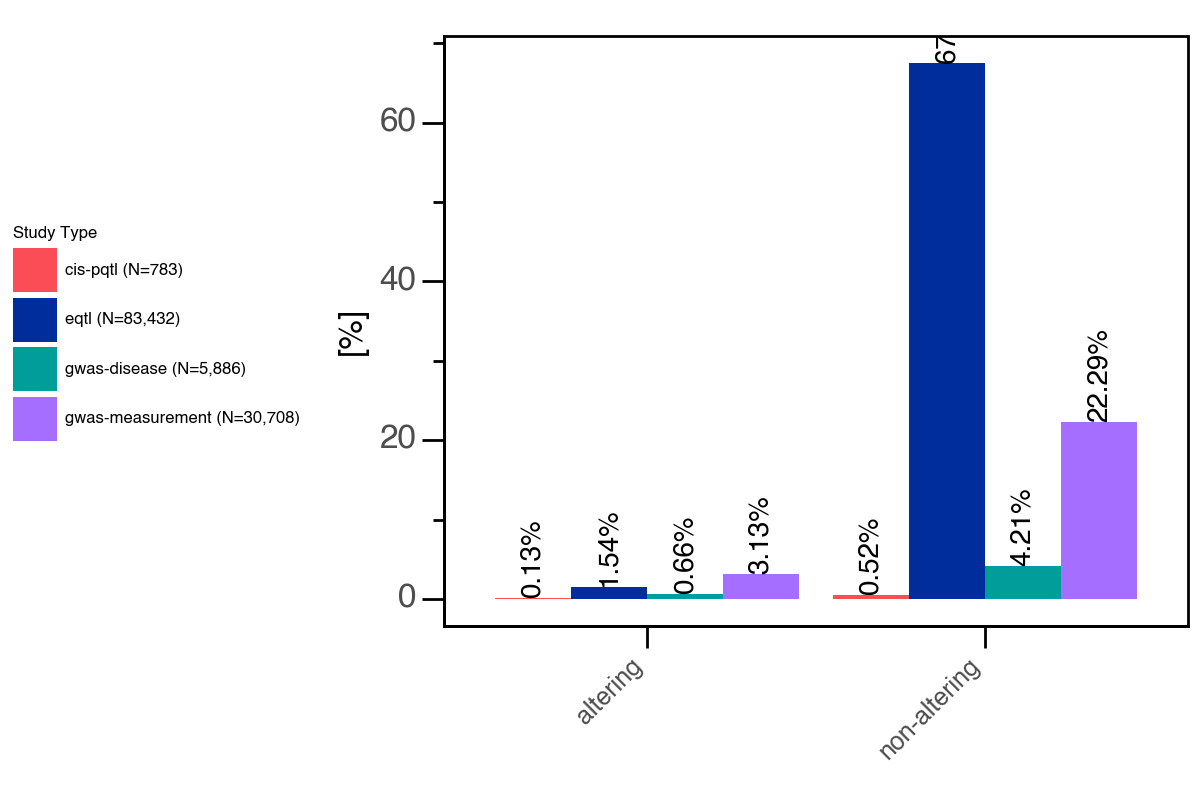

<Figure Size: (600 x 400)>

In [30]:
plot = (
    pn.ggplot(group_data)
    + pn.geom_col(pn.aes(x="variantType", y="percentage", fill="studyType"), position=pn.position_dodge(width=0.9))
    + OpenTargetsTheme.categorical_theme(REM=6)
    + pn.scale_fill_manual(values=OpenTargetsTheme.categorical_dark_colors, name="Study Type", labels=totals_map)
    + pn.geom_text(
        pn.aes(label="label_above", x="variantType", y="percentage", fill="studyType"),
        size=10,
        va="top",
        ha="center",
        color="white",
        position=pn.position_dodge(width=0.9),
        angle=90,
    )
    + pn.geom_text(
        pn.aes(label="label_below", x="variantType", y="percentage", fill="studyType"),
        size=10,
        va="bottom",
        ha="center",
        color="black",
        position=pn.position_dodge(width=0.9),
        angle=90,
    )
    + pn.theme(legend_position="left", figure_size=(6, 4))
    + pn.labs(x="", y="[%]")
)
plot

+------------+------+-----+------------------+
| variantType| count|    %|        percentage|
+------------+------+-----+------------------+
|non-altering|114209|94.54| 94.53683086525011|
|    altering|  6600| 5.46|5.4631691347498945|
+------------+------+-----+------------------+



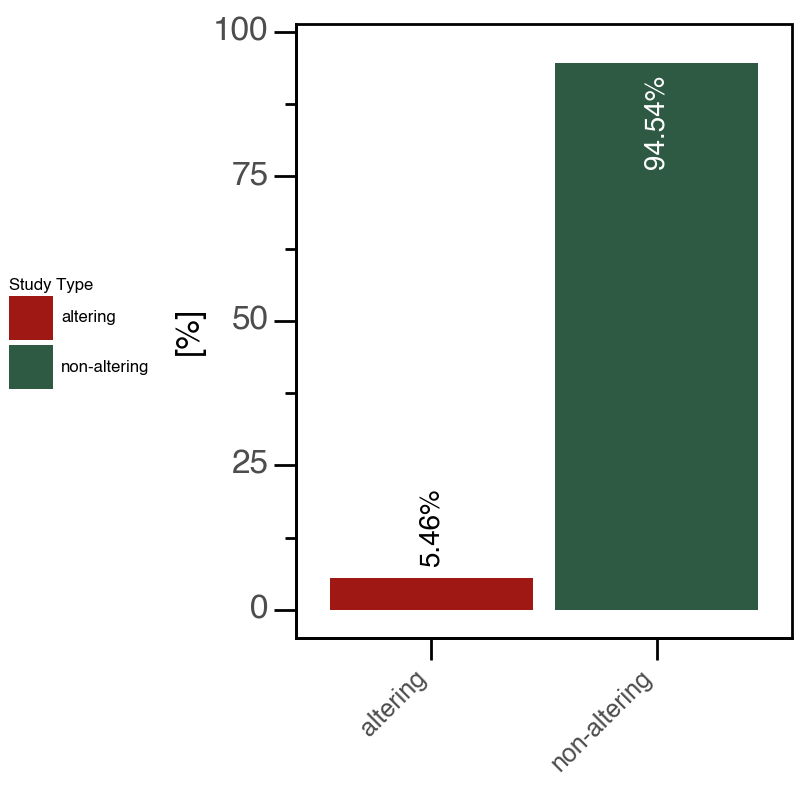

<Figure Size: (400 x 400)>

In [31]:
gs = group_statistics(
    maf_vep_dataset.withColumn(
        "variantType", f.when(f.col("consequenceScore") >= 0.66, "altering").otherwise("non-altering")
    ),
    [f.col("variantType")],
)
gs.show()
group_data = gs.toPandas()
group_data["label_above"] = group_data.apply(lambda x: "" if x["percentage"] < 70 else f"{x['%']}%", axis=1)
group_data["label_below"] = group_data.apply(lambda x: "" if x["percentage"] >= 70 else f"{x['%']}%", axis=1)


plot = (
    pn.ggplot(group_data)
    + pn.geom_col(pn.aes(x="variantType", y="percentage", fill="variantType"))
    + OpenTargetsTheme.categorical_theme(REM=6)
    + pn.scale_fill_manual(
        values=[OpenTargetsTheme.prioritization_colors[0], OpenTargetsTheme.prioritization_colors[-1]],
        name="Study Type",
        labels=totals_map,
    )
    + pn.geom_text(
        pn.aes(label="label_above", x="variantType", y="percentage"),
        size=10,
        va="top",
        ha="center",
        color="white",
        angle=90,
        nudge_y=-2,
    )
    + pn.geom_text(
        pn.aes(label="label_below", x="variantType", y="percentage"),
        size=10,
        va="bottom",
        ha="center",
        color="black",
        angle=90,
        nudge_y=2,
    )
    + pn.theme(legend_position="left", figure_size=(4, 4))
    + pn.labs(x="", y="[%]")
)
plot

## Group statistics by absolute effect size and groups - IGNORE


In [32]:
gs = (
    maf_vep_dataset.withColumn(
        "variantType", f.when(f.col("consequenceScore") >= 0.66, "altering").otherwise("non-altering")
    )
    .withColumn("absEstimatedBeta", f.abs(f.col("estimatedBeta")))
    .toPandas()
    .groupby(["variantType", "studyType"])
    .agg(
        total=("variantId", "count"),
        min=("absEstimatedBeta", lambda x: x.min()),
        max=("absEstimatedBeta", lambda x: x.max()),
        mean=("absEstimatedBeta", lambda x: x.mean()),
        median=("absEstimatedBeta", lambda x: x.median()),
        stddev=("absEstimatedBeta", lambda x: x.std()),
        q25=("absEstimatedBeta", lambda x: x.quantile(0.25)),
        q75=("absEstimatedBeta", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)


# group_data["label_above"] = group_data.apply(lambda x: "" if x["percentage"] < 70 else f"{x['%']}%", axis=1)
# group_data["label_below"] = group_data.apply(lambda x: "" if x["percentage"] >= 70 else f"{x['%']}%", axis=1)
# group_data

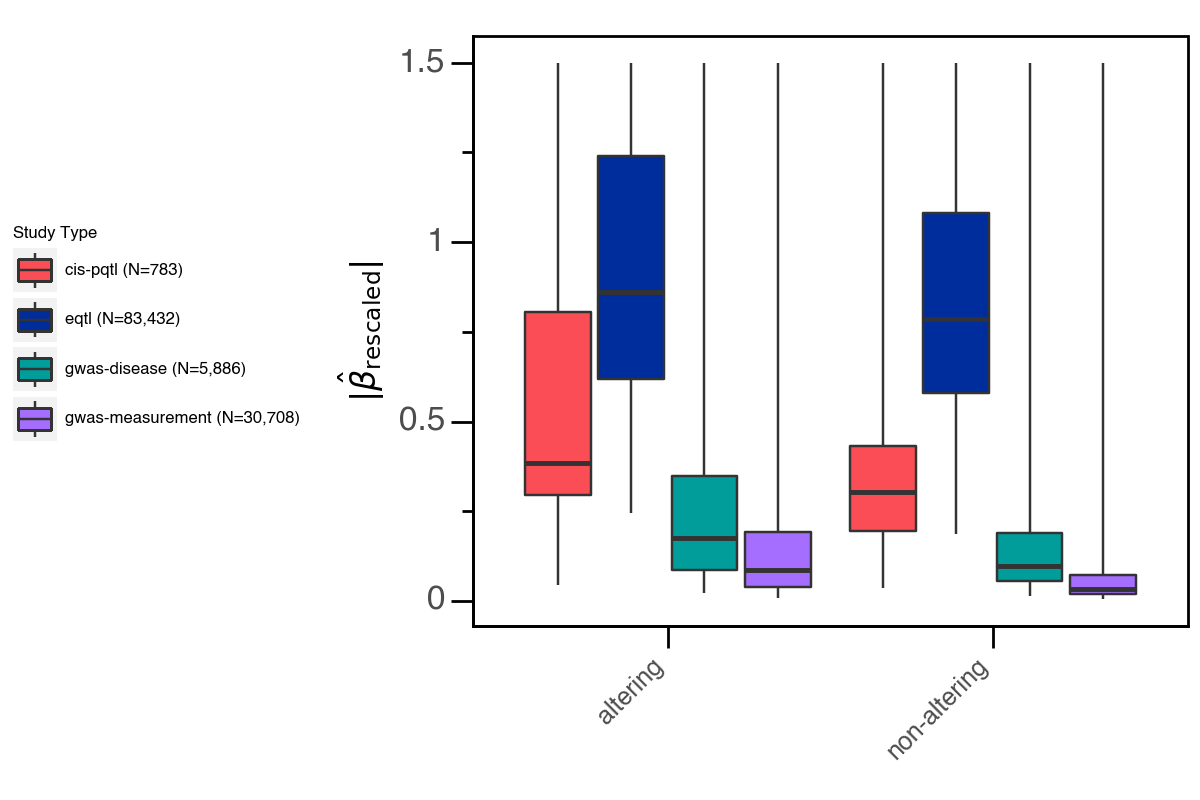

<Figure Size: (600 x 400)>

In [33]:
p = (
    pn.ggplot(gs)
    + pn.geom_boxplot(
        pn.aes(x="variantType", ymin="min", ymax=1.5, middle="median", fill="studyType", upper="q75", lower="q25"),
        stat="identity",
    )
    + OpenTargetsTheme.categorical_theme(REM=6)
    + pn.theme(legend_position="left", figure_size=(6, 4), axis_title_x=pn.element_text(size=10))
    + pn.scale_fill_manual(
        values=OpenTargetsTheme.categorical_dark_colors,
        name="Study Type",
        labels=totals_map,
    )
    + pn.labs(
        x="",
        y=r"$|\hat{\beta}_{\mathrm{rescaled}}|$",
    )
)

p